In [25]:

import pandas as pd

def read_and_clean_data(file_path, sheet_name = 1):
    df = pd.read_excel(file_path, sheet_name = sheet_name)

    #df = df.iloc[1: , 1:]

    df = df.fillna(0)

    #print(df)
    return df


def create_dictionaries(df):
    dictionary = {}

    dictionary1 = {}

    n_rows, n_cols = df.shape
    for i in range(1, n_rows):
        row_key = int(df.iloc[i, 0])
        
        dictionary[row_key] = [] 
        dictionary1[row_key] = set()
        
        for j in range(1, n_cols):
            dictionary[row_key].append((df.iloc[0, j], df.iloc[i, j]))

            if df.iloc[i, j] <= 900:
                dictionary1[row_key].add(df.iloc[0, j])

    return dictionary, dictionary1


df = read_and_clean_data("Data assignment ambulance 2 Small(1).xlsx", sheet_name = 1)
dictionary, dictionary1 = create_dictionaries(df)

print(dictionary) # dictionary is the dictionary which has all the travel times between the postal code so its key(postal code) : tuple(postal code, travel time)
print(dictionary1) # dictionary1 is the dictionary which has all the postal codes that are reachable within 15 minutes for each postal code so its key(postal code) : set

#for key, value in dictionary1.items():
 #   print((key,len(value)))


#for values in dictionary[1117.0]:
 #   print (values[1])










{1117: [(1117.0, 0.0), (1118.0, 630.0), (1119.0, 399.0), (1161.0, 818.0), (1165.0, 894.0), (1171.0, 418.0), (1175.0, 526.0), (1435.0, 653.0), (1436.0, 504.0), (1437.0, 509.0), (1438.0, 284.0), (1911.0, 1497.0), (1941.0, 1229.0), (1942.0, 1226.0), (1943.0, 1311.0), (1944.0, 1367.0), (1945.0, 1343.0), (1946.0, 1318.0), (1947.0, 1272.0), (1948.0, 1119.0), (1949.0, 1448.0), (1951.0, 1292.0), (1961.0, 1564.0), (1962.0, 1498.0), (1963.0, 1524.0), (1964.0, 1531.0), (1965.0, 1465.0), (1966.0, 1381.0), (1967.0, 1357.0), (1968.0, 1670.0), (1969.0, 1588.0), (1971.0, 1251.0), (1972.0, 1462.0), (1973.0, 1395.0), (1974.0, 1488.0), (1975.0, 1451.0), (1976.0, 1566.0), (1981.0, 1201.0), (1985.0, 1252.0), (1991.0, 1306.0), (1992.0, 1271.0), (2011.0, 1007.0), (2012.0, 959.0), (2013.0, 1050.0), (2014.0, 1050.0), (2015.0, 1118.0), (2019.0, 988.0), (2021.0, 1069.0), (2022.0, 1065.0), (2023.0, 1135.0), (2024.0, 1163.0), (2025.0, 1212.0), (2026.0, 1191.0), (2031.0, 924.0), (2032.0, 905.0), (2033.0, 876.0), (2

In [26]:
#the algorithm to find the minimum number of ambulances needed to cover all the areas within 15 minutes

def greedy_algorithm(dictionary1, dictionary, num_ambulances = 2):
    seen = set()

    PD = -1

    max = 0

    PD_list = []

    for i in range(num_ambulances):
        for key, value in dictionary1.items():

            new = len(value - seen)
       

            if new > max:
                # implement something if they can reach the same amount of areas.
                max = new
                PD = key
            elif new == max:
                if PD == -1:
                    PD = key
                else:
                    total1 = 0
                    total2 = 0

                    for pc, time in dictionary[key]:
                        
                        total1 = total1 + time

                    for pc, time in dictionary[PD]:
                    
                        total2 = total2 + time

                    if total1 < total2:
                        PD = key    
        seen = seen.union(dictionary1[PD])
        PD_list.append(PD)
        max = 0
    return PD_list, seen


PD_list, seen = greedy_algorithm(dictionary1, dictionary, num_ambulances = 2)
print(PD_list)

        
        



[2024, 2131]


In [27]:
# we need something to store the demand so we just create a dictionary that stores this.
def create_demand_dictionary(file_path, sheet_name = 2):
    demand_df = read_and_clean_data(file_path, sheet_name = sheet_name)
    
    demand_dictionary = {}
    
    for i in range(0, len(demand_df)):
        postal_code = int(demand_df.iloc[i, 0])
        demand = float(demand_df.iloc[i, 1])
        demand_dictionary[postal_code] = demand
    
    return demand_dictionary

"""we've chosen to just use a sum of the demand of the uncovered areas as our metric to maximize. So we will choose the ambulance location that can cover the most demand in the uncovered areas.
but this isnt necesarily the best"""
def greedy_algorithm_with_demand(dictionary1, dictionary, demand_dictionary, num_ambulances = 2):
    seen = set()

    PD = -1

    max = 0

    PD_list = []

    for i in range(num_ambulances):
        for key, value in dictionary1.items():

            uncovered = value - seen
            weighted_new = sum(demand_dictionary.get(int(pc), 0) for pc in uncovered) # we do get(pc, 0 ) because if the postal code doesnt exist we just return 0 to prevent crashing
       

            if weighted_new > max:
                max = weighted_new
                PD = key
            elif weighted_new == max:
                total1 = 0
                total2 = 0

                for pc, time in dictionary[key]:
                    
                    total1 += time

                for pc, time in dictionary[PD]:
                    
                    total2 += time

                if total1 < total2:
                    PD = key    
        seen = seen.union(dictionary1[PD])
        PD_list.append(PD)
        max = 0
    return PD_list, seen


demand_dictionary = create_demand_dictionary("Data assignment ambulance 2 Small(1).xlsx", sheet_name = 2)
PD_list_demand, seen_demand = greedy_algorithm_with_demand(dictionary1, dictionary, demand_dictionary, num_ambulances = 2)
print(PD_list_demand)

#a function we use to calculate the demand score for a given set 
def score(covered_set, demand_dictionary):
    score = 0
    for pc in covered_set:
        score = score + demand_dictionary.get(int(pc), 0)
    return score


total_covered_demand = score(seen_demand, demand_dictionary)


print(total_covered_demand)


[2024, 2131]
519457.0


In [ ]:
import itertools
"""we test how well the greedy algorithm performs on the 2 datasets"""

# so this is just a brute force algorithm that will provide a optimal solution but its a non polynomial time algoithm so its not viable for large datasets
def brute_force(dictionary1, demand_dictionary, num_ambulances = 2):
    candidates = list(dictionary1.keys())
    k = num_ambulances

    best_choice = None
    best_score = -1

    for choice in itertools.combinations(candidates, k):
        covered = set() # We use itertools to generate all combinations of candidates of size k
        for pd in choice:
            covered = covered.union(dictionary1[pd])

        score_val = score(covered, demand_dictionary)

        if score_val > best_score:
            best_score = score_val
            best_choice = list(choice)

    return best_choice, best_score


# the small dataset
df_small = read_and_clean_data("Data assignment ambulance 2 Small(1).xlsx", sheet_name = 1)
dictionary_small, dictionary_small1 = create_dictionaries(df_small)
demand_dictionary_small = create_demand_dictionary("Data assignment ambulance 2 Small(1).xlsx", sheet_name = 2)

PD_list_small, seen_demand_small = greedy_algorithm_with_demand(dictionary_small1, dictionary_small, demand_dictionary_small, num_ambulances = 2)
total_covered_demand_small = score(seen_demand_small, demand_dictionary_small)
print("Greedy small ->", total_covered_demand_small)

# brute force for small dataset
optimal_choice_small, optimal_score_small = brute_force(dictionary_small1, demand_dictionary_small, num_ambulances = 2)
print("Brute small ->", optimal_score_small, "choice:", optimal_choice_small)
print("Ratio greedy/optimal:", (total_covered_demand_small / optimal_score_small) if optimal_score_small>0 else float('nan'))



#the large dataset
df_large = read_and_clean_data("Data assignment ambulance 2 Large.xlsx", sheet_name = 1)
dictionary_large, dictionary_large1 = create_dictionaries(df_large)
demand_dictionary_large = create_demand_dictionary("Data assignment ambulance 2 Large.xlsx", sheet_name = 2)

PD_list_large, seen_demand_large = greedy_algorithm_with_demand(dictionary_large1, dictionary_large, demand_dictionary_large, num_ambulances = 5)
total_covered_demand_large = score(seen_demand_large, demand_dictionary_large)
print("Greedy large ->", total_covered_demand_large)

"""unfortunately the brute force algorithm is not runnable in a reasonable time for the large dataset so we will just have to test the performance on smaller datasets
and hope the trend will continue for larger datasets"""


Greedy small -> 519457.0
Brute small -> 519457.0 choice: [1435, 2024]
Ratio greedy/optimal: 1.0
Greedy large -> 1038095.0


'unfortunately the brute force algorithm is not runnable in a reasonable time for the large dataset so we will just have to test the performance on smaller datasets\nand hope the trend will continue for larger datasets'

In [29]:
import random
"""in this cell we determine how well the greedy algorithm performs on a random test graph/matrix. We compare the solution of the greedy algorithm
to the optimal solution (which we compute by using the brute force algorithm). And then eventually we report the accuracy"""

# so here we build the random test cases we dont actually create the matrix (the excel file) we just create the dictionary's that the algorithm needs
def generate_random_instance(num_postal_codes = 20, edge_probability = 0.35): # default values for postal codes and edge prob
    # we use an edge probability later in the code the purpose of this is to be able to fine tune the amount of postal codes we can reach and see what impact that will have on the algorithm performance.
    postal_codes = [1000 + i for i in range(num_postal_codes)]

    dictionary = {}
    dictionary1 = {}
    demand_dictionary = {}

    for pc in postal_codes:
        demand_dictionary[pc] = random.randint(1, 500) # we assign random demands to every postal code

    for i in postal_codes:
        dictionary[i] = []
        dictionary1[i] = set()

        for j in postal_codes:
            if i == j:
                travel_time = 0
            else:
                if random.random() < edge_probability:
                    travel_time = random.randint(300, 900)
                else:
                    travel_time = random.randint(901, 1800)

            dictionary[i].append((j, float(travel_time)))

            if travel_time <= 900:
                dictionary1[i].add(j)

    return dictionary, dictionary1, demand_dictionary


# here we actually run the expirment.
def run_accuracy_experiment(
    num_cases = 100,
    num_postal_codes = 30,
    num_ambulances = 5,
    edge_prob = 0.35,
    random_seed = 42 # we use a random seed so that we can reproduce the result.
    ):
    random.seed(random_seed)

    exact_matches = 0
    ratios = []

    for i in range(num_cases):
        dictionary_test, dictionary1_test, demand_test = generate_random_instance(
            num_postal_codes = num_postal_codes,
            edge_probability = edge_prob
        )

        seen = greedy_algorithm_with_demand(
            dictionary1_test, dictionary_test, demand_test, num_ambulances = num_ambulances
        )[1]
        greedy_score = score(seen, demand_test)

        optimal_score = brute_force(
            dictionary1_test, demand_test, num_ambulances = num_ambulances
        )[1]

        ratio = greedy_score / optimal_score
        ratios.append(ratio)

        if greedy_score == optimal_score:
            exact_matches = exact_matches + 1

    results = {
        "how many cases": num_cases,
        "num_PD": num_postal_codes,
        "ambulances": num_ambulances,
        "exact_match": exact_matches / num_cases,
        "average_ratio": sum(ratios) / len(ratios),
        "worst_ratio": min(ratios)
    }
    return results

print("100-case experiment")
results_100 = run_accuracy_experiment(num_cases = 100, num_postal_codes = 20, num_ambulances = 2)
print(results_100)

print("1000-case experiment")
results_1000 = run_accuracy_experiment(num_cases = 1000, num_postal_codes = 20, num_ambulances = 2)
print(results_1000)

100-case experiment
{'how many cases': 100, 'num_PD': 20, 'ambulances': 2, 'exact_match': 0.66, 'average_ratio': 0.9866873424485983, 'worst_ratio': 0.8566293085218862}
1000-case experiment
{'how many cases': 1000, 'num_PD': 20, 'ambulances': 2, 'exact_match': 0.642, 'average_ratio': 0.9856366232297856, 'worst_ratio': 0.8464558342420938}


In [30]:
# simple tailored examples where demand-greedy can perform badly

def run_example_title(title):
    print("=" * 70)
    print(title)


def run_example(title, demand_dict, cover_sets, in_time_map, num_ambulances, why_bad):
    dictionary1 = {}
    dictionary = {}

    for station, covered_set in cover_sets.items():
        dictionary1[station] = set(covered_set)
        dictionary[station] = []
        for pc in demand_dict:
            time_value = in_time_map.get((station, pc), 500) if pc in covered_set else 1800
            dictionary[station].append((pc, float(time_value)))

    greedy_choice, greedy_seen = greedy_algorithm_with_demand(
        dictionary1, dictionary, demand_dict, num_ambulances = num_ambulances
)
    greedy_score = score(greedy_seen, demand_dict)

    optimal_choice, optimal_score = brute_force(
        dictionary1, demand_dict, num_ambulances = num_ambulances
)

    run_example_title(title)
    print("greedy choice:", greedy_choice)
    print("optimal choice:", optimal_choice)
    print("greedy score:", greedy_score)
    print("optimal score:", optimal_score)
    print("ratio:", greedy_score / optimal_score)
    print("why bad:", why_bad)


# Example 1 (k=2): tie-break overlap trap
demand_ex1 = {1001: 1, 1002: 1, 1003: 1, 1004: 1}
cover_ex1 = {
    1010: {1001, 1002},
    1020: {1001, 1003},
    1030: {1002, 1004}
}
in_time_ex1 = {
    (1010, 1001): 10, (1010, 1002): 10,
    (1020, 1001): 400, (1020, 1003): 400,
    (1030, 1002): 400, (1030, 1004): 400
}

run_example(
    "Example 1 (k=2): tie-break overlap trap",
    demand_ex1,
    cover_ex1,
    in_time_ex1,
    2,
    "first choice is tie-broken toward a set that overlaps both alternatives, so total union is smaller."
    )

# Example 2 (k=2): high-demand overlap trap
demand_ex2 = {
    2001: 40, 2002: 40, 2003: 40, 2004: 40,
    2005: 35, 2006: 35, 2007: 35, 2008: 35
}
cover_ex2 = {
    2010: {2001, 2002, 2003, 2004},
    2020: {2001, 2002, 2005, 2006},
    2030: {2003, 2004, 2007, 2008}
}
in_time_ex2 = {}

run_example(
    "Example 2 (k=2): high-demand overlap trap",
    demand_ex2,
    cover_ex2,
    in_time_ex2,
    2,
    "greedy takes the largest immediate set first, but that set overlaps heavily and blocks a better pair."
    )

# Example 3 (k=3): cascading overlap trap
demand_ex3 = {
    3001: 20, 3002: 20, 3003: 20, 3004: 20, 3005: 20, 3006: 20,
    3007: 39, 3008: 39, 3009: 39, 3010: 39, 3011: 39, 3012: 39
}
cover_ex3 = {
    3010: {3001, 3002, 3003, 3004, 3005, 3006},
    3020: {3001, 3002, 3007, 3008},
    3030: {3003, 3004, 3009, 3010},
    3040: {3005, 3006, 3011, 3012}
}
in_time_ex3 = {}

run_example(
    "Example 3 (k=3): cascading overlap trap",
    demand_ex3,
    cover_ex3,
    in_time_ex3,
    3,
    "the first greedy pick consumes shared core demand, so later marginals are weaker than the best 3-set combination."
    )

print("=" * 70)
k = 2
print("theoretical bound for k=2:", 1 - ((k - 1) / k) ** k)
k = 3
print("theoretical bound for k=3:", 1 - ((k - 1) / k) ** k)

Example 1 (k=2): tie-break overlap trap
greedy choice: [1010, 1020]
optimal choice: [1020, 1030]
greedy score: 3
optimal score: 4
ratio: 0.75
why bad: first choice is tie-broken toward a set that overlaps both alternatives, so total union is smaller.
Example 2 (k=2): high-demand overlap trap
greedy choice: [2010, 2020]
optimal choice: [2020, 2030]
greedy score: 230
optimal score: 300
ratio: 0.7666666666666667
why bad: greedy takes the largest immediate set first, but that set overlaps heavily and blocks a better pair.
Example 3 (k=3): cascading overlap trap
greedy choice: [3010, 3020, 3030]
optimal choice: [3020, 3030, 3040]
greedy score: 276
optimal score: 354
ratio: 0.7796610169491526
why bad: the first greedy pick consumes shared core demand, so later marginals are weaker than the best 3-set combination.
theoretical bound for k=2: 0.75
theoretical bound for k=3: 0.7037037037037037


In [ ]:
import math
"""so the idea of this experiment is to create test cases that are similar to an actual city. For me the easiest way to do this is to give every postal code an actual location (x,y)
and then determine the travle time based on their position in the 2d plane. To make it realistic i have created a city center so more postal codes in the middle"""


def generate_city(num_PC, R):
    PC = [1000 + i for i in range(num_PC)] # i use this numbering bcs this was also used in the excel files
    # we create the usual dictionaries again
    dictionary = {} # PC: (PC, travel time)
    dictionary1 = {} # PC: set of PCs reachable within 15 minutes
    demand_dictionary = {} # PC: demand
    locations = {} # PC: (x, y)

    centers = [(R / 8, 0), (0, R / 8), (-R / 8, 0), (0, -R / 8)] # we create 4 centers in the city to make it more realistic and make it a bit harder for the greedy algorithm
    cluster_radius = R * 0.9

    for pc in PC:
        cx, cy = random.choice(centers)
        angle = random.random() * 2 * math.pi
        distance = (random.random() ** 2) * cluster_radius

        x = cx + distance * math.cos(angle) 
        y = cy + distance * math.sin(angle)
        locations[pc] = (x, y)

        dem_bonus = 1 - (distance / cluster_radius)
        demand_dictionary[pc] = random.randint(1, 500) + int(400 * dem_bonus) #this is so that it will hopefully represent a city center better.
    
    for i in PC:
        dictionary[i] = []
        dictionary1[i] = set()

        for j in PC:
            if i == j:
                travel_time = 0
            else:
                (x1, y1) = locations[i]
                (x2, y2) = locations[j]
                distance = math.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)
                average_speed = 45 # so we have the coordinates of the locations and their distance we somehow need to convert this to travel time so lets just define a speed at which the ambulances travel
                travel_time = int((distance / average_speed) * 3600)
                travel_time = travel_time + random.randint(20, 90) # add some randomness

            dictionary[i].append((j, float(travel_time)))
            if travel_time <= 900:
                dictionary1[i].add(j)
    return dictionary, dictionary1, demand_dictionary

# this function is from cell 5 just tweaked a little to make it work for our test cases.
def run_accuracy_experiment_city(
    num_cases = 100,
    num_postal_codes = 30,
    num_ambulances = 2,
    city_radius = 80,
    random_seed = 42 # we use a random seed so that we can reproduce the result.
    ):
    random.seed(random_seed)

    exact_matches = 0
    ratios = []

    for i in range(num_cases):
        dictionary_test, dictionary1_test, demand_test = generate_city(
            num_postal_codes, city_radius
        )

        seen = greedy_algorithm_with_demand(
            dictionary1_test, dictionary_test, demand_test, num_ambulances = num_ambulances
        )[1]
        greedy_score = score(seen, demand_test)

        optimal_score = brute_force(
            dictionary1_test, demand_test, num_ambulances = num_ambulances
        )[1]

        ratio = greedy_score / optimal_score if optimal_score > 0 else float("nan")
        ratios.append(ratio)

        if greedy_score == optimal_score:
            exact_matches = exact_matches + 1

    results = {
        "how many cases": num_cases,
        "num_PD": num_postal_codes,
        "ambulances": num_ambulances,
        "exact_match": exact_matches / num_cases,
        "average_ratio": sum(ratios) / len(ratios),
        "worst_ratio": min(ratios)
    }
    return results


print("city experiment (100 cases)")
results_city_100 = run_accuracy_experiment_city(num_cases = 40, num_postal_codes = 40, num_ambulances = 4, city_radius = 60)
print(results_city_100)

print("city experiment (1000 cases)") 
results_city_1000 = run_accuracy_experiment_city(num_cases = 1000, num_postal_codes = 50, num_ambulances = 2, city_radius = 100)
print(results_city_1000)

city experiment (100 cases)
{'how many cases': 40, 'num_PD': 40, 'ambulances': 4, 'exact_match': 0.35, 'average_ratio': 0.9765885186217942, 'worst_ratio': 0.9290931858499426}
city experiment (1000 cases)
{'how many cases': 1000, 'num_PD': 50, 'ambulances': 2, 'exact_match': 0.845, 'average_ratio': 0.9930689448394634, 'worst_ratio': 0.844705688918119}


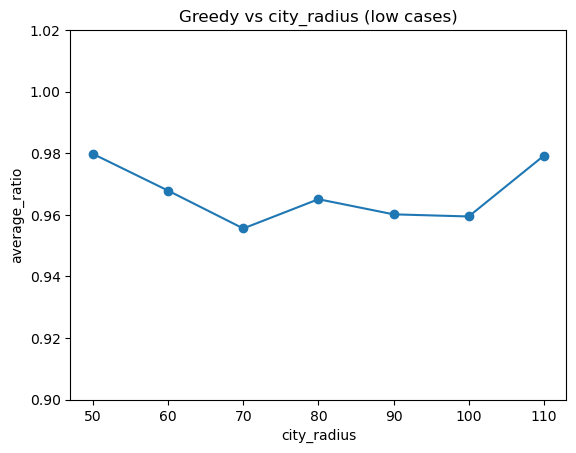

In [33]:
import matplotlib.pyplot as plt

radii = [50, 60, 70, 80, 90, 100, 110]
avg_ratios = []

for r in radii:
    res = run_accuracy_experiment_city(
        num_cases = 6,
        num_postal_codes = 80,
        num_ambulances = 3,
        city_radius = r
    )
    avg_ratios.append(res["average_ratio"])

plt.plot(radii, avg_ratios, marker = "o")
plt.ylim(0.9, 1.02)
plt.xlabel("city_radius")
plt.ylabel("average_ratio")
plt.title("Greedy vs city_radius (low cases)")
plt.show()

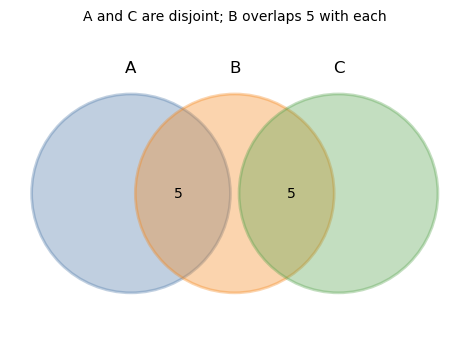

In [34]:
# Simple Venn-style diagram: all circles, A and C disjoint; B overlaps 5 with each.

import matplotlib.pyplot as plt
from matplotlib.patches import Circle


fig, ax = plt.subplots(figsize=(5.8, 4.2))
colors = {"A": "#4C78A8", "B": "#F58518", "C": "#54A24B"}

# Circle geometry: A and C just disjoint; B overlaps each more.
center_a = (-1.2, 0.0)
center_b = (0.0, 0.0)
center_c = (1.2, 0.0)
radius_a = 1.15
radius_b = 1.15
radius_c = 1.15

circle_a = Circle(center_a, radius_a, facecolor=colors["A"], edgecolor=colors["A"], alpha=0.35, linewidth=2.0)
circle_b = Circle(center_b, radius_b, facecolor=colors["B"], edgecolor=colors["B"], alpha=0.35, linewidth=2.0)
circle_c = Circle(center_c, radius_c, facecolor=colors["C"], edgecolor=colors["C"], alpha=0.35, linewidth=2.0)

ax.add_patch(circle_a)
ax.add_patch(circle_b)
ax.add_patch(circle_c)

# Set labels.
ax.text(center_a[0], 1.45, "A", ha="center", va="center", fontsize=12)
ax.text(center_b[0], 1.45, "B", ha="center", va="center", fontsize=12)
ax.text(center_c[0], 1.45, "C", ha="center", va="center", fontsize=12)

# Overlap labels for A∩B and B∩C.
ax.text(-0.65, 0.0, "5", ha="center", va="center", fontsize=10)
ax.text(0.65, 0.0, "5", ha="center", va="center", fontsize=10)

ax.set_title("A and C are disjoint; B overlaps 5 with each", fontsize=10)
ax.set_aspect("equal")
ax.set_xlim(-2.6, 2.6)
ax.set_ylim(-1.8, 1.9)
ax.axis("off")
plt.show()